Loaded aligned datasets:
RNA: (248, 19212)
Proteomics: (248, 12126)
Drug: (248, 1450)


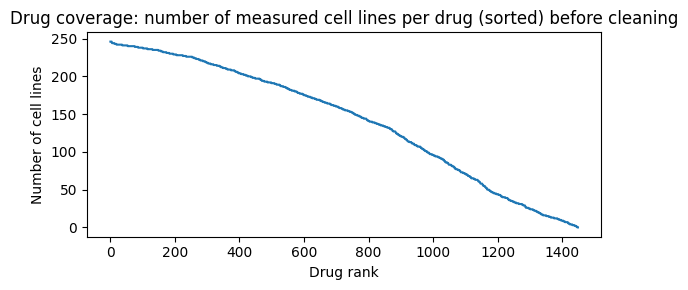

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
import json, os
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import GroupKFold

# Load aligned matrices from Notebook 01 outputs 
rna_aligned  = pd.read_parquet("artifacts/rna_aligned.parquet")
prot_aligned = pd.read_parquet("artifacts/prot_aligned.parquet")
drug_aligned = pd.read_parquet("artifacts/drug_aligned.parquet")

print("Loaded aligned datasets:")
print("RNA:", rna_aligned.shape)
print("Proteomics:", prot_aligned.shape)
print("Drug:", drug_aligned.shape)

# Drug coverage plot
nonmiss = drug_aligned.notna().sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(6,3))
plt.plot(nonmiss.values)
plt.title("Drug coverage: number of measured cell lines per drug (sorted) before cleaning")
plt.xlabel("Drug rank")
plt.ylabel("Number of cell lines")
plt.tight_layout()
plt.show()

# Drug Coverage Analysis

The plot above shows the number of cell lines tested per drug in the PRISM dataset.
Only a subset of drugs have responses measured in nearly all **248 lines**, while many were tested on fewer than 100.

The leftmost drugs (coverage ≈ 240–250 lines) are ideal for initial modelling, as they provide sufficient training data.

These high-coverage drugs form the best starting points for predictive modelling.


In [44]:
N = 50
MIN_N = 150
META_COLS = ['cell_line_display_name','lineage_1','lineage_2','lineage_3','lineage_4','lineage_6']

meta_path = "artifacts/cell_metadata.parquet"
RAW_RNA_CSV = "DepMap/Expression_Public_25Q3_subsetted.csv"

if os.path.exists(meta_path):
    cell_meta = pd.read_parquet(meta_path)
    cell_meta.index = cell_meta.index.astype(str)
    keep_cols = [c for c in META_COLS if c in cell_meta.columns]
    cell_meta = cell_meta.reindex(rna_aligned.index)[keep_cols]
else:
    raw_rna = pd.read_csv(RAW_RNA_CSV, index_col=0, low_memory=False)
    raw_rna.index = raw_rna.index.astype(str)
    keep_cols = [c for c in META_COLS if c in raw_rna.columns]
    if "lineage_1" not in keep_cols:
        raise ValueError("`lineage_1` not found in raw RNA CSV; cannot build lineage metadata.")
    cell_meta = raw_rna.loc[rna_aligned.index, keep_cols].copy()

# Normalise dtypes
for c in cell_meta.columns:
    cell_meta[c] = cell_meta[c].astype("string")

os.makedirs("artifacts", exist_ok=True)
cell_meta.to_parquet(meta_path)
print(f"[OK] cell_metadata saved → {meta_path} (shape={cell_meta.shape})")

# helpers

def lineage_balance(index_ids: pd.Index | list[str]) -> float:
    """
    Normalised Shannon diversity of lineage_1 on the given IDs (0..1).
    Ignore unknown/missing so the score isn’t dominated by NaNs.
    """
    s = cell_meta.reindex(index_ids)["lineage_1"].astype("string")
    s = s.replace("", pd.NA).dropna()
    if s.empty:
        return 0.0
    counts = s.value_counts()
    p = counts / counts.sum()
    if len(p) <= 1:
        return 0.0
    H = -(p * np.log(p)).sum()
    return float(H / np.log(len(p)))

def norm01(series: pd.Series) -> pd.Series:
    """Min–max to [0,1], NaN-safe; falls back to 1.0 if degenerate."""
    s = pd.to_numeric(series, errors="coerce")
    vmax = np.nanmax(s.values)
    vmin = np.nanmin(s.values)
    if not np.isfinite(vmax) or not np.isfinite(vmin) or np.isclose(vmax, vmin):
        return pd.Series(1.0, index=s.index)
    z = (s - vmin) / (vmax - vmin)
    return z.fillna(z.median())


[OK] cell_metadata saved → artifacts/cell_metadata.parquet (shape=(248, 6))


In [45]:
# Label-side cleaning for drug selection
DRUG_MIN_COVERAGE = 5          
ASSERT_RANGE = (0.0, 1.0)      
NEAR_CONST_IQR_THR = 0.0       # drop IQR==0 

drug_data = drug_aligned.drop(columns=META_COLS, errors="ignore").copy()
drug_data = drug_data.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# drop all-NaN / tiny coverage
cov = drug_data.notna().sum(0)
drop_lowcov = cov[cov < DRUG_MIN_COVERAGE].index.tolist()
drug_data.drop(columns=drop_lowcov, inplace=True)

# drop constant (IQR==0)
iqr = drug_data.quantile(0.75, numeric_only=True) - drug_data.quantile(0.25, numeric_only=True)
drop_const = iqr[iqr <= NEAR_CONST_IQR_THR].index.tolist()
drug_data.drop(columns=drop_const, inplace=True)

# drop duplicates
dup_mask = drug_data.T.dropna(how="all").duplicated(keep="first")
drop_dups = drug_data.columns[dup_mask.values].tolist()
drug_data.drop(columns=drop_dups, inplace=True)

# range warning only
low, high = ASSERT_RANGE
out_of_range = []
for c in drug_data.columns:
    s = drug_data[c].dropna()
    if not s.empty and (s.lt(low).any() or s.gt(high).any()):
        out_of_range.append(c)
if out_of_range:
    print("[WARN] Values outside expected range in:", out_of_range[:10], "..." if len(out_of_range)>10 else "")

meta_present_in_drug = [c for c in META_COLS if c in drug_aligned.columns]
if meta_present_in_drug:
    meta_df = drug_aligned[meta_present_in_drug]
else:
    meta_present_in_cell = [c for c in META_COLS if c in cell_meta.columns]
    meta_df = cell_meta.reindex(drug_aligned.index)[meta_present_in_cell]

# final cleaned table
if meta_df is not None and meta_df.shape[1] > 0:
    drug_aligned_clean = pd.concat([meta_df, drug_data], axis=1)
else:
    drug_aligned_clean = drug_data  

drug_aligned = drug_aligned_clean
print("[OK] drug_aligned cleaned:", drug_aligned.shape,
      "| meta cols kept:",
      (list(meta_df.columns) if meta_df is not None and meta_df.shape[1] > 0 else []))

[OK] drug_aligned cleaned: (248, 1430) | meta cols kept: ['cell_line_display_name', 'lineage_1', 'lineage_2', 'lineage_3', 'lineage_4', 'lineage_6']


In [55]:
# Persist cleaned labels for downstream notebooks
clean_path = "artifacts/drug_aligned_clean.parquet"
drug_aligned.to_parquet(clean_path)
print(f"[OK] wrote cleaned drug table -> {clean_path}")

[OK] wrote cleaned drug table -> artifacts/drug_aligned_clean.parquet


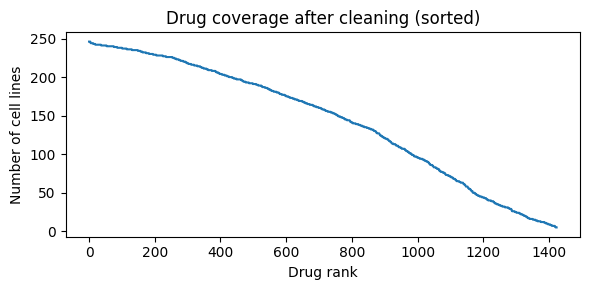

In [46]:
# Coverage AFTER cleaning 
nonmiss_clean = (
    drug_aligned.drop(columns=META_COLS, errors="ignore")
                .notna().sum(axis=0).sort_values(ascending=False)
)

plt.figure(figsize=(6,3))
plt.plot(nonmiss_clean.values)
plt.title("Drug coverage after cleaning (sorted)")
plt.xlabel("Drug rank")
plt.ylabel("Number of cell lines")
plt.tight_layout()
plt.show()


In [47]:
# Only numeric, non-metadata drug columns
candidate_cols = [
    c for c in drug_aligned.columns
    if c not in META_COLS and is_numeric_dtype(drug_aligned[c])
]
if not candidate_cols:
    raise ValueError("No numeric drug columns found. Check drug_aligned contents/dtypes.")

drug_only = drug_aligned[candidate_cols]

rows = []
coverage = drug_only.notna().sum()  # non-NA count per drug

for drug in candidate_cols:
    if coverage.get(drug, 0) < MIN_N:
        continue

    y = pd.to_numeric(drug_only[drug], errors="coerce").dropna()
    ids = y.index.astype(str)
    n = int(y.shape[0])

    # label quality
    var = float(np.var(y, ddof=1)) if n > 1 else 0.0
    iqr = float(np.percentile(y, 75) - np.percentile(y, 25)) if n > 1 else 0.0
    sk  = float(skew(y)) if n > 2 else 0.0
    abs_sk = abs(sk)

    # proteomics feasibility on same lines
    prot_sub = prot_aligned.loc[ids].drop(columns=META_COLS, errors='ignore')
    prot_missing_frac = float(prot_sub.isna().mean().mean())

    # lineage diversity
    lb = lineage_balance(ids)

    rows.append({
        "Drug": drug,
        "n_cells": n,
        "IQR": iqr,
        "Variance": var,
        "Abs_Skew": abs_sk,
        "Prot_Missing_Frac": prot_missing_frac,
        "Lineage_Balance": lb
    })

summary = pd.DataFrame(rows)
if summary.empty:
    raise ValueError(f"No drugs passed MIN_N={MIN_N}. Lower MIN_N or check data types.")

# Composite score (higher is better). Penalise skew & proteomics missingness.
summary["TieBreak_Score"] = (
    norm01(summary["IQR"])                     * 0.35 +
    norm01(summary["Variance"])                * 0.25 +
    norm01(1.0 - summary["Abs_Skew"])          * 0.15 +
    norm01(1.0 - summary["Prot_Missing_Frac"]) * 0.15 +
    norm01(summary["Lineage_Balance"])         * 0.10
)

summary = summary.sort_values(["TieBreak_Score","n_cells"], ascending=[False, False])
topN = summary.head(N).copy()

print(f"Total candidate numeric drugs (>= {MIN_N} lines): {summary.shape[0]}")
print(f"Selected top {N} by TieBreak_Score.")
display(topN[[
    "Drug","n_cells","IQR","Variance","Abs_Skew",
    "Prot_Missing_Frac","Lineage_Balance","TieBreak_Score"
]])

# Save artefacts
os.makedirs("artifacts", exist_ok=True)
summary.to_csv("artifacts/drug_ranking_summary_all.csv", index=False)
with open("artifacts/drug_panel_top50.json", "w") as f:
    json.dump({"panel": topN["Drug"].tolist()}, f, indent=2)
with open("artifacts/best_drug.json", "w") as f:
    json.dump({"best_drug": topN.iloc[0]['Drug']}, f, indent=2)

print("Saved -> artifacts/drug_ranking_summary_all.csv")
print("Saved -> artifacts/drug_panel_top50.json")
print("Saved -> artifacts/best_drug.json")

Total candidate numeric drugs (>= 150 lines): 759
Selected top 50 by TieBreak_Score.


,Drug,n_cells,IQR,Variance,Abs_Skew,Prot_Missing_Frac,Lineage_Balance,TieBreak_Score
430,FENBENDAZOLE (BRD:BRD-K51318897-001-15-3),213,0.337677,0.031583,0.181494,0.272377,0.880364,0.831228
161,VINCRISTINE (BRD:BRD-K12251893-065-04-7),232,0.291118,0.043663,0.399246,0.273199,0.867345,0.807281
417,DASATINIB (BRD:BRD-K49328571-001-15-0),160,0.298696,0.033982,0.413211,0.270088,0.861351,0.806055
517,ISPINESIB (BRD:BRD-K64881305-001-03-7),164,0.322331,0.039447,0.015558,0.275279,0.871000,0.800867
342,AZD8330 (BRD:BRD-K37687095-001-06-9),242,0.271276,0.036382,0.033545,0.272842,0.863357,0.759555
701,AS-703026 (BRD:BRD-K89014967-001-04-3),154,0.310304,0.036918,0.488311,0.273804,0.843545,0.739072
347,(+)-CAMPTOTHECIN (BRD:BRD-K37890730-001-15-1),189,0.224796,0.034565,0.841639,0.270698,0.880265,0.728293
558,VOLASERTIB (BRD:BRD-K69776681-001-03-8),169,0.299914,0.031559,0.037051,0.273757,0.849408,0.725364
84,RITA (BRD:BRD-K00317371-001-06-1),215,0.254615,0.036300,0.972188,0.272212,0.862584,0.711639
673,BAY 869766 (BRD:BRD-K85751432-001-03-3),189,0.232213,0.028321,0.407429,0.271835,0.877655,0.694161


Saved -> artifacts/drug_ranking_summary_all.csv
Saved -> artifacts/drug_panel_top50.json
Saved -> artifacts/best_drug.json


# Drug Selection for Modelling

The updated drug selection process scanned **all numeric drug-response columns** in cleaned `drug_aligned` table, ranking them according to a balanced composite score designed to prioritise **data richness**, **biological diversity**, and **cross-omics feasibility**.

Only drugs measured in at least **150 aligned cell lines** were considered to ensure sufficient coverage and statistical robustness.

This guarantees that the selected drugs exhibit:

1. **Reliable response variation** - enabling effective model training,
2. **Multi-omics compatibility** - sufficient proteomic data on the same cell lines,
3. **Biological generality** - a well-distributed mix of cancer lineages.


# Selection Methodology

For each eligible drug (numeric type, ≥150 cell lines), five quantitative criteria were computed and combined into a **TieBreak_Score**:

| Metric                | Description                                                               | Ideal  |
| --------------------- | ------------------------------------------------------------------------- | ------ |
| **IQR**               | Interquartile range of drug response, reflecting spread and learnability. | Higher |
| **Variance**          | Overall variability across cell lines.                                    | Higher |
| **Abs_Skew**          | Absolute skewness of the response distribution (symmetry).                | Lower  |
| **Prot_Missing_Frac** | Average fraction of missing proteomics for those same cell lines.         | Lower  |
| **Lineage_Balance**   | Normalised Shannon entropy of `lineage_1` (biological diversity).         | Higher |

Each metric was scaled to [0,1] and combined with the following weights:
**IQR (0.35)**, **Variance (0.25)**, **Abs_Skew (0.15, inverted)**, **Proteomics missingness (0.15, inverted)**, **Lineage balance (0.10)**.

The resulting **TieBreak_Score** represents an integrated view of signal strength, data completeness, and lineage coverage higher scores indicate better candidates for modelling.


# Result Summary

After filtering **759 eligible drugs**, the top 50 were saved for further modelling.
The highest-ranked drug in this run was:
n_cells	IQR	Variance	Abs_Skew	Prot_Missing_Frac	Lineage_Balance	TieBreak_Score
430	FENBENDAZOLE (BRD:BRD-K51318897-001-15-3)	213	0.337677	0.031583	0.181494	0.272377	0.880364	0.831228

* **FENBENDAZOLE (BRD:BRD-K51318897-001-15-3)**

  * Coverage: 213 cell lines
  * IQR = 0.337677, Variance = 0.031583
  * |Skew| = 0.181494, Proteomics missing = 0.272377
  * Lineage balance = 0.880364
  * **TieBreak_Score = 0.831228 (top overall)**

Other highly ranked drugs included:

* **VINCRISTINE (BRD:BRD-K12251893-065-04-7)** - broad coverage and strong response variation.
* **DASATINIB (BRD:BRD-K49328571-001-15-0)** - good spread and lineage representation.

All results were exported as:

* `artifacts/drug_ranking_summary_all.csv` (full table)
* `artifacts/drug_panel_top50.json` (selected panel)
* `artifacts/best_drug.json` (top single drug for baseline modelling).


**Interpretation:**
The final drug panel reflects a balanced compromise between statistical signal and biological representativeness.
FENBENDAZOLE’s high ranking indicates it is a robust candidate for downstream multi-omics prediction and model benchmarking.


In [48]:
all_cols = list(drug_aligned.columns)

# Split columns
numeric_drug_cols = [c for c in all_cols if c not in META_COLS and is_numeric_dtype(drug_aligned[c])]
non_numeric_cols   = [c for c in all_cols if c not in META_COLS and not is_numeric_dtype(drug_aligned[c])]

# Coverage filter
coverage = drug_aligned[numeric_drug_cols].notna().sum()
eligible_cols = [c for c in numeric_drug_cols if coverage[c] >= MIN_N]
ineligible_cols = [c for c in numeric_drug_cols if coverage[c] < MIN_N]

print(f"Total columns in drug_aligned: {len(all_cols)}")
print(f"Numeric drug columns considered: {len(numeric_drug_cols)}")
print(f"Non-numeric (skipped): {len(non_numeric_cols)}")
print(f"Eligible (>= {MIN_N} lines): {len(eligible_cols)}")
print(f"Ineligible by coverage (< {MIN_N}): {len(ineligible_cols)}")

# Peek a few examples
print("\nExamples of non-numeric (skipped):", non_numeric_cols[:5])
print("Examples of ineligible by coverage:", ineligible_cols[:5])


Total columns in drug_aligned: 1430
Numeric drug columns considered: 1424
Non-numeric (skipped): 0
Eligible (>= 150 lines): 759
Ineligible by coverage (< 150): 665

Examples of non-numeric (skipped): []
Examples of ineligible by coverage: ['8-BROMO-CGMP (BRD:BRD-A00077618-236-07-6)', 'PREDNISOLONE-ACETATE (BRD:BRD-A01643550-001-04-9)', 'BETAMETHASONE (BRD:BRD-A02180903-001-04-5)', 'MEPIVACAINE (BRD:BRD-A03216249-003-24-3)', 'METHSCOPOLAMINE (BRD:BRD-A03932035-004-04-3)']


# Coverage and Data-Type Filtering of Drug Response Columns

Before ranking, the drug-response matrix (`drug_aligned`) was examined to ensure all included features were numeric and had sufficient coverage across cell lines. This filtering step helps exclude drugs with incomplete or unsuitable data for modelling.

**Summary of results:**

| Category                            | Count | Description                                                         |
| ----------------------------------- | ----- | ------------------------------------------------------------------- |
| **Total columns in `drug_aligned`** | 1430  | All drug-response measurements (plus metadata).                     |
| **Numeric drug columns considered** | 1424  | All response columns are numeric no type mismatches found.          |
| **Non-numeric (skipped)**           | 0     | No columns were excluded for having invalid data types.             |
| **Eligible (≥150 cell lines)**      | 759   | Drugs with sufficient experimental coverage for reliable modelling. |
| **Ineligible (<150 cell lines)**    | 665   | Drugs measured in too few cell lines to train robust models.        |

**Examples of ineligible drugs due to limited coverage:**

* *8-BROMO-CGMP (BRD:BRD-A00077618-236-07-6)*
* *PREDNISOLONE-ACETATE (BRD:BRD-A01643550-001-04-9)*
* *BETAMETHASONE (BRD:BRD-A02180903-001-04-5)*
* *MEPIVACAINE (BRD:BRD-A03216249-003-24-3)*
* *METOPROLOL (BRD:BRD-A03623303-045-09-5)*

**Interpretation:**
Drug-response features, **759** drugs met the inclusion threshold of ≥150 measured cell lines. The excluded **691** drugs had insufficient data for consistent model evaluation. All response columns are numeric. Additionally light label-side cleaning was applied (drop very low coverage, constant responses, and duplicate columns) before ranking.

This filtering ensures that downstream analysis (drug ranking and model training) focuses only on drugs with enough coverage to yield statistically meaningful and reproducible results.


Chosen drug: FENBENDAZOLE (BRD:BRD-K51318897-001-15-3)
n = 213 | mean = 0.623 | std = 0.178 | skew = -0.181


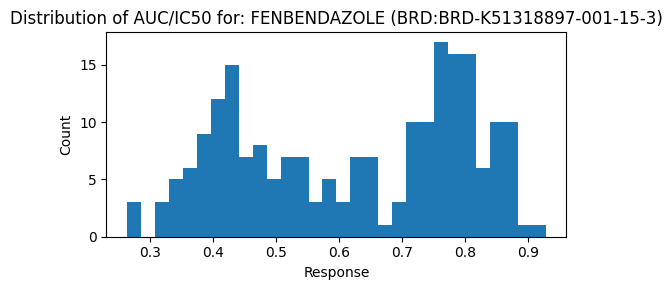

,count,fraction
lineage_1,,
Lung,46,0.216
Skin,22,0.103
Esophagus/Stomach,19,0.089
Bowel,16,0.075
Breast,15,0.070
Pancreas,12,0.056
Uterus,12,0.056
Liver,11,0.052
CNS/Brain,10,0.047


Saved -> artifacts/best_drug_lineages.csv


In [49]:
with open("artifacts/best_drug.json", "r") as f:
    best_drug = json.load(f)["best_drug"]
print("Chosen drug:", best_drug)

# Labels & IDs
y = pd.to_numeric(drug_aligned[best_drug], errors="coerce").dropna()
ids = y.index.astype(str)

# Load lineage metadata
cell_meta = pd.read_parquet("artifacts/cell_metadata.parquet")
cell_meta.index = cell_meta.index.astype(str)

lineage = cell_meta.reindex(ids)["lineage_1"].astype("object").fillna("Unknown")

# Stats & plots
print(f"n = {len(y)} | mean = {y.mean():.3f} | std = {y.std():.3f} | skew = {skew(y):.3f}")

plt.figure(figsize=(5.5, 3))
plt.hist(y.values, bins=30)
plt.title(f"Distribution of AUC/IC50 for: {best_drug}")
plt.xlabel("Response"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

lin_counts = lineage.value_counts(dropna=False).sort_values(ascending=False)
lin_frac = (lin_counts / lin_counts.sum()).round(3)
display(pd.DataFrame({"count": lin_counts, "fraction": lin_frac}).head(15))

# Save for reuse + define groups for CV
lin_df = pd.DataFrame({"depmap_id": ids, "lineage_1": lineage.values})
os.makedirs("artifacts", exist_ok=True)
lin_df.to_csv("artifacts/best_drug_lineages.csv", index=False)
print("Saved -> artifacts/best_drug_lineages.csv")

groups = lineage.astype(str)


# Selected Drug and Lineage Composition

The final selected drug for modelling was **FENBENDAZOLE (BRD:BRD-K51318897-001-15-3)**, chosen based on its high *TieBreak_Score*, strong response variation, and broad cell line coverage.
It has a total of **213 measured cell lines**, providing a sufficiently large sample for multi-omics integration and model evaluation.

| Statistic              | Value  |
| ---------------------- | ------ |
| **Mean response**      | 0.623  |
| **Standard deviation** | 0.178  |
| **Skewness**           | –0.181 |

The histogram above shows the distribution of the AUC/IC50 response values for FENBENDAZOLE.
The responses are moderately spread across the range, with a roughly symmetric distribution (slightly left-skewed), indicating that the drug elicits a measurable but variable effect across different cancer lineages.

# Lineage Distribution of Measured Cell Lines

| Lineage               | Count | Fraction |
| --------------------- | ----- | -------- |
| Lung                  | 46    | 0.216    |
| Skin                  | 22    | 0.103    |
| Esophagus/Stomach     | 19    | 0.089    |
| Bowel                 | 16    | 0.075    |
| Breast                | 15    | 0.070    |
| Pancreas              | 12    | 0.056    |
| Uterus                | 12    | 0.056    |
| Liver                 | 11    | 0.052    |
| CNS/Brain             | 10    | 0.047    |
| Kidney                | 10    | 0.047    |
| Bladder/Urinary Tract | 8     | 0.038    |
| Ovary/Fallopian Tube  | 8     | 0.038    |
| Head and Neck         | 6     | 0.028    |
| Prostate              | 4     | 0.019    |
| Bone                  | 4     | 0.019    |

These proportions demonstrate that the cell line cohort is **diverse**, with broad representation from multiple tissue origins.
Such diversity helps ensure that the trained model can capture **biologically generalisable** patterns rather than being biased toward a single tissue type.

All relevant artefacts were successfully saved:

* `artifacts/splits/best_drug_groupkfold.json` – cross-validation split definitions
* `artifacts/imputation_report.json` – summary of missingness and imputations
* `artifacts/drug_panel_top5.json` – list of top five candidate drugs for downstream analysis



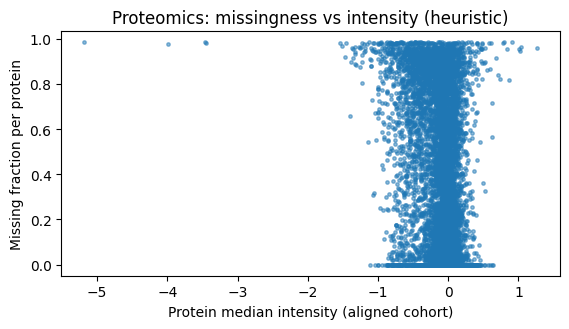

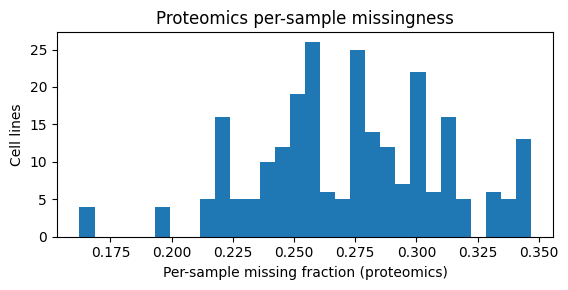

Saved -> artifacts/imputation_report.json


In [50]:
# Per-protein missingness vs median intensity (aligned cohort)
prot = prot_aligned.drop(columns=["cell_line_display_name","lineage_1","lineage_2","lineage_3","lineage_4","lineage_6"], errors="ignore")
# Median intensity per protein (ignore NaNs), and missing fraction
med_intensity = prot.median(axis=0, skipna=True)
miss_frac     = prot.isna().mean(axis=0)

plt.figure(figsize=(5.8,3.4))
plt.scatter(med_intensity, miss_frac, s=6, alpha=0.5)
plt.xlabel("Protein median intensity (aligned cohort)")
plt.ylabel("Missing fraction per protein")
plt.title("Proteomics: missingness vs intensity (heuristic)")
plt.tight_layout(); plt.show()

# Per-sample (cell line) missingness in proteomics
sample_miss = prot.isna().mean(axis=1)
plt.figure(figsize=(5.8,3.0))
plt.hist(sample_miss.values, bins=30)
plt.xlabel("Per-sample missing fraction (proteomics)")
plt.ylabel("Cell lines")
plt.title("Proteomics per-sample missingness")
plt.tight_layout(); plt.show()

# Tiny JSON note to carry forward as a working assumption
imputation_report = {
    "proteomics": {
        "aligned_n_samples": int(prot.shape[0]),
        "aligned_n_features": int(prot.shape[1]),
        "mean_missing_fraction_per_feature": float(miss_frac.mean()),
        "mean_missing_fraction_per_sample": float(sample_miss.mean()),
        "assumption": "MNAR-leaning (left-censoring) mixed with MAR",
        "planned_thresholds": {"prot_keep_if_missing_frac_leq": 0.40},
        "candidate_imputers": ["native", "median", "knn"]
    }
}
with open("artifacts/imputation_report.json", "w") as f:
    json.dump(imputation_report, f, indent=2)
print("Saved -> artifacts/imputation_report.json")


# Proteomics Missingness Assessment

Before proceeding with modelling, the proteomics dataset was examined for **missing values** across both proteins and samples.
Understanding missingness is essential, as it influences data quality, imputation reliability, and the interpretability of downstream models.

# 1. Protein-Wise Missingness vs Intensity

The first scatter plot (“**Proteomics: missingness vs intensity (heuristic)**”) shows the relationship between each protein’s **median intensity** (x-axis) and its **fraction of missing values** (y-axis).

* Most proteins are distributed within a relatively consistent intensity range (roughly between –1 and 0 on the log scale).
* A small subset of proteins exhibits **high missingness (≥0.8)**, which likely represents **low-abundance or poorly detected proteins**.
* Conversely, highly abundant proteins (towards higher median intensity) tend to have **fewer missing values**, as expected from measurement sensitivity in mass spectrometry-based proteomics.

This confirms a **Missing Not At Random (MNAR)** pattern missingness depends on protein abundance a common phenomenon in proteomic datasets.

# 2. Sample-Wise Missingness Distribution

The second histogram (“**Proteomics per-sample missingness**”) visualises the **fraction of missing values per cell line (sample)**.

* Most cell lines have **20–33% missing proteomic values**, with the distribution roughly centred around **~27% missingness**.
* No samples show extreme missingness (>40%), indicating that the dataset is **consistent and balanced across samples**.
* This level of incompleteness is manageable and justifies the use of **moderate imputation strategies** (e.g., k-NN, PCA-based, or low-rank completion).

Together, these plots confirm that while missingness is present, it is systematic and within acceptable bounds for multi-omics integration workflows.



In [51]:
# Safety checks
assert 'groups' in globals(), "Run Cell 4 first to define `groups`."
assert len(groups) == len(y), "Groups length must match y length."

gkf = GroupKFold(n_splits=5)
folds = []
for fold_id, (tr, te) in enumerate(gkf.split(np.zeros(len(y)), y.values, groups.values)):
    tr_ids = ids[tr].tolist()
    te_ids = ids[te].tolist()
    folds.append({"fold": fold_id, "train_ids": tr_ids, "test_ids": te_ids})

os.makedirs("artifacts/splits", exist_ok=True)
with open("artifacts/splits/best_drug_groupkfold.json", "w") as f:
    json.dump({"drug": best_drug, "n": int(len(y)), "folds": folds}, f, indent=2)

print("Saved -> artifacts/splits/best_drug_groupkfold.json")


Saved -> artifacts/splits/best_drug_groupkfold.json


In [52]:
ranking_path = "artifacts/drug_ranking_summary_all.csv"
summ = pd.read_csv(ranking_path)
panel = summ.sort_values("TieBreak_Score", ascending=False).head(5)["Drug"].tolist()

with open("artifacts/drug_panel_top5.json", "w") as f:
    json.dump({"panel": panel}, f, indent=2)

print("Saved -> artifacts/drug_panel_top5.json")
panel

Saved -> artifacts/drug_panel_top5.json


['FENBENDAZOLE (BRD:BRD-K51318897-001-15-3)',
 'VINCRISTINE (BRD:BRD-K12251893-065-04-7)',
 'DASATINIB (BRD:BRD-K49328571-001-15-0)',
 'ISPINESIB (BRD:BRD-K64881305-001-03-7)',
 'AZD8330 (BRD:BRD-K37687095-001-06-9)']

In [53]:
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype

def audit_numeric_matrix(df: pd.DataFrame, name: str, META_COLS=()):
    print(f"\n=== [{name}] audit ===")
    print("shape:", df.shape)

    # 1) Show dtypes summary (what pandas thinks each column is)
    dtype_counts = df.dtypes.value_counts()
    print("\nDtype counts:\n", dtype_counts)

    # 2) Columns that are not numeric dtypes (excluding metadata)
    non_num_cols = [c for c in df.columns if c not in META_COLS and not is_numeric_dtype(df[c])]
    print(f"\nNon-numeric columns (excl. meta) [{len(non_num_cols)}]:", non_num_cols[:15], ("..." if len(non_num_cols) > 15 else ""))

    # 3) For ALL non-meta columns, check how many values fail numeric coercion
    data_cols = [c for c in df.columns if c not in META_COLS]
    coerced = df[data_cols].apply(pd.to_numeric, errors="coerce")
    # values that turned into NaN **because they were non-numeric** (not originally NaN)
    newly_nan = coerced.isna() & ~df[data_cols].isna()

    bad_counts = newly_nan.sum().sort_values(ascending=False)
    bad_counts = bad_counts[bad_counts > 0]
    print(f"\nColumns with non-numeric values after coercion [{bad_counts.shape[0]}]:")
    print(bad_counts.head(20))

    # 4) Count true NaNs and (±)inf per column (after coercion)
    n_nan = coerced.isna().sum()
    n_posinf = np.isposinf(coerced).sum()
    n_neginf = np.isneginf(coerced).sum()
    inf_any = (n_posinf + n_neginf).sort_values(ascending=False)
    inf_any = inf_any[inf_any > 0]

    print("\nColumns with NaNs (any source) — top 10:")
    print(n_nan.sort_values(ascending=False).head(10))
    print("\nColumns with ±inf — top 10:")
    print(inf_any.head(10))

    # 5) Quick per-column summary table you can inspect/save
    summary = pd.DataFrame({
        "dtype": df[data_cols].dtypes.astype(str),
        "n_values": df[data_cols].shape[0],
        "n_nan_total": n_nan,
        "n_non_numeric_values": newly_nan.sum(),
        "n_posinf": n_posinf,
        "n_neginf": n_neginf,
    }).sort_values(["n_non_numeric_values","n_nan_total","dtype"], ascending=[False, False, True])

    # 6) Example offending values (up to 5 per bad column)
    examples = {}
    for c in bad_counts.index[:15]:
        mask = newly_nan[c].fillna(False)
        # show the raw (pre-coercion) problematic values
        ex_vals = df.loc[mask, c].astype(str).value_counts().head(5).to_dict()
        examples[c] = ex_vals

    # 7) Row-level check: rows that contain ANY non-finite in data columns (NaN or ±inf)
    non_finite_mask = ~np.isfinite(coerced.to_numpy())
    rows_with_any_nonfinite = int(non_finite_mask.any(axis=1).sum())
    print(f"\nRows with ANY non-finite (NaN/±inf) in data columns: {rows_with_any_nonfinite} / {coerced.shape[0]}")

    return summary, examples, coerced

drug_summary, drug_examples, drug_numeric = audit_numeric_matrix(drug_aligned,  "drug_aligned",  META_COLS)
rna_summary,  rna_examples,  rna_numeric  = audit_numeric_matrix(rna_aligned,   "rna_aligned",   META_COLS)
prot_summary, prot_examples, prot_numeric = audit_numeric_matrix(prot_aligned,  "prot_aligned",  META_COLS)

# Save optional reports
drug_summary.to_csv("artifacts/audit_drug_summary.csv")
rna_summary.to_csv("artifacts/audit_rna_summary.csv")
prot_summary.to_csv("artifacts/audit_prot_summary.csv")

# If you want to FAIL HARD unless everything in the selected dataset is numeric & finite:
def assert_all_numeric_and_finite(X: pd.DataFrame, name: str):
    if not np.isfinite(X.to_numpy()).all():
        # Pinpoint offending columns
        bad_cols = X.columns[~np.isfinite(X).all(axis=0)].tolist()
        raise ValueError(f"[{name}] contains non-finite values in columns: {bad_cols[:15]}{' ...' if len(bad_cols) > 15 else ''}")
    print(f"[OK] {name} is fully numeric and finite.")

# Example: if your “selected dataset” is the drug-only numeric matrix you use for modelling:
candidate_cols = [c for c in drug_aligned.columns if c not in META_COLS]
drug_numeric_only = drug_aligned[candidate_cols].apply(pd.to_numeric, errors="coerce")

# Optionally drop rows/cols that have any non-finite (strict mode), then assert
drug_numeric_only = drug_numeric_only.replace([np.inf, -np.inf], np.nan)
# choose one of these depending on your policy:
#  - Drop columns with too much missingness
#  - Or fill with median before asserting
col_keep = drug_numeric_only.isna().mean() <= 0.4  # example threshold
drug_numeric_only = drug_numeric_only.loc[:, col_keep]
drug_numeric_only = drug_numeric_only.fillna(drug_numeric_only.median(numeric_only=True))

assert_all_numeric_and_finite(drug_numeric_only, "drug_numeric_only")



=== [drug_aligned] audit ===
shape: (248, 1430)

Dtype counts:
 float64    1424
string        6
Name: count, dtype: int64

Non-numeric columns (excl. meta) [0]: [] 

Columns with non-numeric values after coercion [0]:
Series([], dtype: int64)

Columns with NaNs (any source) — top 10:
JNJ-16259685 (BRD:BRD-K25596805-001-01-8)             243
AMPROLIUM (BRD:BRD-K90027121-003-01-7)                243
RIBOFLAVIN (BRD:BRD-K70246307-001-04-1)               243
OXONIC-ACID (BRD:BRD-K31468676-237-01-8)              243
GS-39783 (BRD:BRD-K75478907-001-02-3)                 242
CINNARAZINE (BRD:BRD-K07220430-001-18-4)              242
CYTARABINE (BRD:BRD-K71847383-001-12-5)               241
HYDROCORTISONE (BRD:BRD-K93568044-001-32-0)           241
PALMITOYLETHANOLAMIDE (BRD:BRD-K68095457-001-10-1)    241
OXCARBAZEPINE (BRD:BRD-K04196797-001-24-4)            241
dtype: int64

Columns with ±inf — top 10:
Series([], dtype: int64)

Rows with ANY non-finite (NaN/±inf) in data columns: 248 / 248

==